Done: /kaggle/working/coin_dataset/train → moved 1096 images into class folders.
Done: /kaggle/working/coin_dataset/valid → moved 161 images into class folders.
Done: /kaggle/working/coin_dataset/test → moved 305 images into class folders.
------------------------------
Total Images      : 8906
Train images      : 6221 (69.9%)
Validation images : 897 (10.1%)
Test images       : 1788 (20.1%)
Classes found     : ['0', '1', '2', '3', '4', '5']


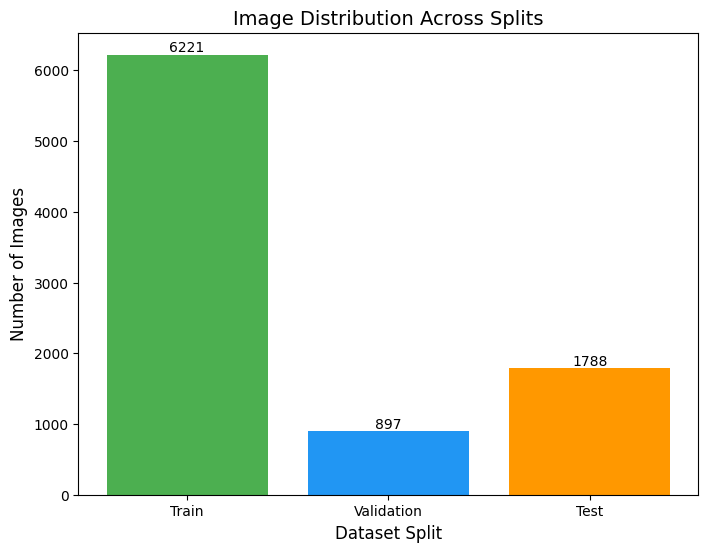

In [1]:
import os
import shutil
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. PATH DEFINITIONS
# Source (Read-only)
input_path = "/kaggle/input/datasets/tasnia12456/coin-dataset/Final_Balanced_Coin_Dataset"
# Destination (Writable)
working_path = "/kaggle/working/coin_dataset"

# 2. COPY DATASET TO WORKING DIRECTORY
# This is required because we need to move files around
if os.path.exists(working_path):
    shutil.rmtree(working_path) # Clean start if exists
shutil.copytree(input_path, working_path)

train_dir = os.path.join(working_path, "train")
val_dir   = os.path.join(working_path, "valid")
test_dir  = os.path.join(working_path, "test")

# 3. DEFINE LABEL MAP AND MOVE LOGIC
label_map = {"1f": "0", "2f": "1", "5f": "2", "1b": "3", "2b": "4", "5b": "5"}

def move_unlabeled_images(base_dir):
    unlabeled_path = os.path.join(base_dir, "unlabeled")
    if not os.path.exists(unlabeled_path):
        print(f"Skipping {base_dir}: No 'unlabeled' folder found.")
        return
    
    moved_count = 0
    for img_name in os.listdir(unlabeled_path):
        prefix = img_name.split("_")[0]
        if prefix in label_map:
            target_class = label_map[prefix]
            target_dir = os.path.join(base_dir, target_class)
            os.makedirs(target_dir, exist_ok=True)
            shutil.move(os.path.join(unlabeled_path, img_name),
                        os.path.join(target_dir, img_name))
            moved_count += 1
            
    # Clean up empty unlabeled folder
    if len(os.listdir(unlabeled_path)) == 0:
        os.rmdir(unlabeled_path)
    print(f"Done: {base_dir} → moved {moved_count} images into class folders.")

# Execute moving
for split in [train_dir, val_dir, test_dir]:
    move_unlabeled_images(split)

# 4. IMAGE LOADING & TRANSFORMS
IMG_SIZE = 224
BATCH_SIZE = 32

data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=data_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=data_transforms)

# 5. DATASET STATISTICS & RATIOS
train_count = len(train_dataset)
val_count   = len(val_dataset)
test_count  = len(test_dataset)
total_count = train_count + val_count + test_count

print("-" * 30)
print(f"Total Images      : {total_count}")
print(f"Train images      : {train_count} ({train_count/total_count:.1%})")
print(f"Validation images : {val_count} ({val_count/total_count:.1%})")
print(f"Test images       : {test_count} ({test_count/total_count:.1%})")
print(f"Classes found     : {train_dataset.classes}")

# 6. PLOT BAR DISTRIBUTION
splits = ['Train', 'Validation', 'Test']
counts = [train_count, val_count, test_count]

plt.figure(figsize=(8, 6))
bars = plt.bar(splits, counts, color=['#4CAF50', '#2196F3', '#FF9800'])
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Image Distribution Across Splits', fontsize=14)

# Add count labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')

plt.show()

Training ShuffleNet on cuda...


Epoch 1/100: 100%|██████████| 195/195 [00:46<00:00,  4.21it/s, loss=0.626]


Epoch 1 | Train Loss: 1.0696 Acc: 0.5850 | Val Loss: 0.9835 Acc: 0.6332
Model saved (improvement found)


Epoch 2/100: 100%|██████████| 195/195 [00:44<00:00,  4.40it/s, loss=0.41] 


Epoch 2 | Train Loss: 0.5623 Acc: 0.7939 | Val Loss: 0.6529 Acc: 0.7960
Model saved (improvement found)


...

Epoch 15 | Train Loss: 0.0499 Acc: 0.9842 | Val Loss: 0.4609 Acc: 0.8696


Epoch 16/100: 100%|██████████| 195/195 [00:43<00:00,  4.53it/s, loss=0.00971]


Epoch 16 | Train Loss: 0.0584 Acc: 0.9793 | Val Loss: 0.7398 Acc: 0.8071


Epoch 17/100: 100%|██████████| 195/195 [00:43<00:00,  4.49it/s, loss=0.173]  


Epoch 17 | Train Loss: 0.0646 Acc: 0.9781 | Val Loss: 0.1756 Acc: 0.9420
Early stopping triggered after 5 epochs.


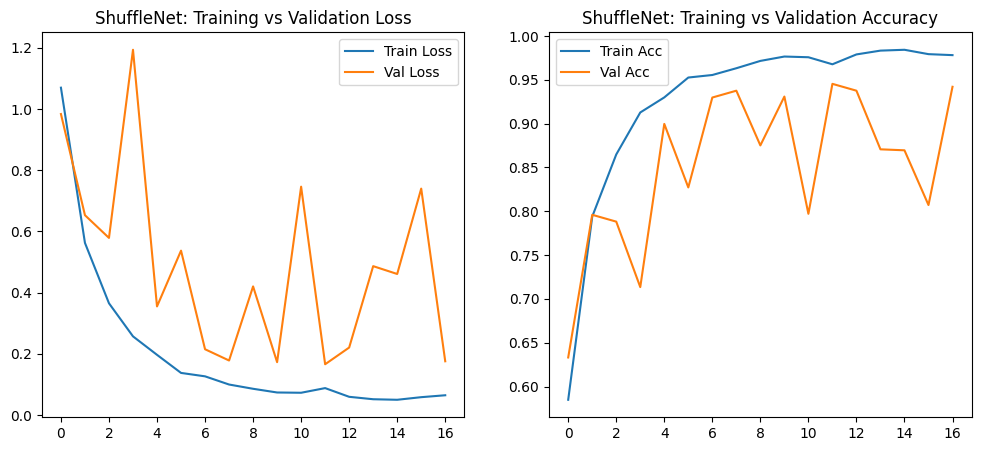

In [2]:
from sklearn.metrics import accuracy_score
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader 


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = 6 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.shufflenet_v2_x1_0(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)   

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def get_metrics(loader, model):
    model.eval()
    all_labels, all_preds = [], []
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    return acc, val_loss / len(loader.dataset)


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
print(f"Training ShuffleNet on {device}...")

patience = 5
best_val_loss = float('inf')
counter = 0
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        
        pbar.set_postfix(loss=loss.item())

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)
    
    epoch_val_acc, epoch_val_loss = get_metrics(val_loader, model)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc.item())
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_shufflenet_model.pth')
        print("Model saved (improvement found)")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered after {patience} epochs.")
            break


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('ShuffleNet: Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('ShuffleNet: Training vs Validation Accuracy')
plt.legend()
plt.show()

 Successfully loaded best model weights.

Metric          | Train Set    | Test Set    
---------------------------------------------
Accuracy        | 0.9786       | 0.9497      
Precision       | 0.9792       | 0.9522      
Recall          | 0.9786       | 0.9497      
F1 Score        | 0.9787       | 0.9503      

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       336
           1       0.95      0.96      0.96       322
           2       0.99      0.94      0.97       543
           3       0.94      0.94      0.94       188
           4       0.82      0.93      0.87       183
           5       0.98      0.98      0.98       216

    accuracy                           0.95      1788
   macro avg       0.94      0.95      0.94      1788
weighted avg       0.95      0.95      0.95      1788



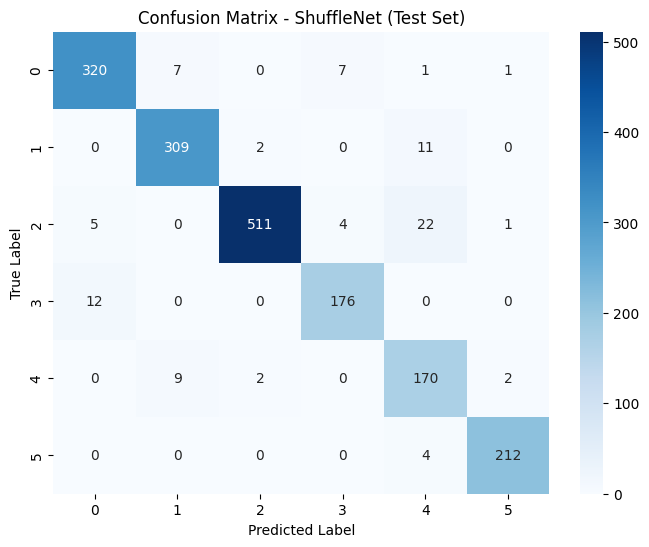

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import torch


test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
eval_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)


if os.path.exists('best_shufflenet_model.pth'):
    model.load_state_dict(torch.load('best_shufflenet_model.pth'))
    print(" Successfully loaded best model weights.")

def get_predictions(loader):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)


y_train_true, y_train_pred = get_predictions(eval_train_loader)
y_test_true, y_test_pred   = get_predictions(test_loader)

print("\n" + "="*45)
print(f"{'Metric':<15} | {'Train Set':<12} | {'Test Set':<12}")
print("-" * 45)
metrics = [
    ("Accuracy", accuracy_score),
    ("Precision", lambda t, p: precision_score(t, p, average='weighted')),
    ("Recall", lambda t, p: recall_score(t, p, average='weighted')),
    ("F1 Score", lambda t, p: f1_score(t, p, average='weighted'))
]
for name, func in metrics:
    train_val = func(y_train_true, y_train_pred)
    test_val  = func(y_test_true, y_test_pred)
    print(f"{name:<15} | {train_val:<12.4f} | {test_val:<12.4f}")
print("="*45)


target_names = [str(i) for i in range(num_classes)]

print("\nClassification Report:\n")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))


cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ShuffleNet (Test Set)")
plt.show()